In [6]:
import tensorflow as tf
from tensorflow import keras

#**Problema 1**

# Introducción a las redes convolucionales (convnets)


Primero veremos un ejemplo muy sencillo de **convnet**. La usaremos para clasificar dígitos MNIST.

Las líneas de código siguientes muestran la estructura básica: una pila de capas `Conv2D` y `MaxPooling2D`. Enseguida veremos qué hacen en la práctica.

Una convnet espera tensores de forma `(alto_imagen, ancho_imagen, canales)` (sin contar la dimensión del lote). Aquí configuramos la entrada como `(28, 28, 1)`, el formato de las imágenes MNIST, pasando `input_shape=(28, 28, 1)` a la primera capa.


In [7]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mostremos la arquitectura de la convnet hasta ahora:


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

Arriba se ve que la salida de cada capa `Conv2D` y `MaxPooling2D` es un tensor 3D de forma `(alto, ancho, canales)`. Las dimensiones alto y ancho suelen reducirse al profundizar en la red. El número de canales lo fija el primer argumento de `Conv2D` (por ejemplo 32 o 64).

El siguiente paso es conectar el último tensor de salida (forma `(3, 3, 64)`) a un clasificador **densamente conectado**, como las pilas de capas `Dense` que ya conoces. Esas capas procesan vectores 1D, mientras que aquí la salida es 3D. Por tanto, primero **aplanamos** la salida 3D a 1D y luego añadimos capas `Dense`:


In [9]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

Haremos una clasificación en **10 clases**, así que la última capa tiene 10 salidas y activación `softmax`. Así queda la red completa:


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Como ves, las salidas `(3, 3, 64)` se convierten en vectores de forma `(576,)` antes de pasar por las dos capas `Dense`.

Ahora entrenemos la convnet con los dígitos MNIST.


In [11]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
print(train_images.shape)
print(train_labels.shape)

(60000, 28, 28, 1)
(60000, 10)


In [13]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - accuracy: 0.9431 - loss: 0.1848 - val_accuracy: 0.9847 - val_loss: 0.0473
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.9857 - loss: 0.0465 - val_accuracy: 0.9867 - val_loss: 0.0395
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9900 - loss: 0.0320 - val_accuracy: 0.9891 - val_loss: 0.0350
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9924 - loss: 0.0236 - val_accuracy: 0.9900 - val_loss: 0.0321
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.9917 - val_loss: 0.0263


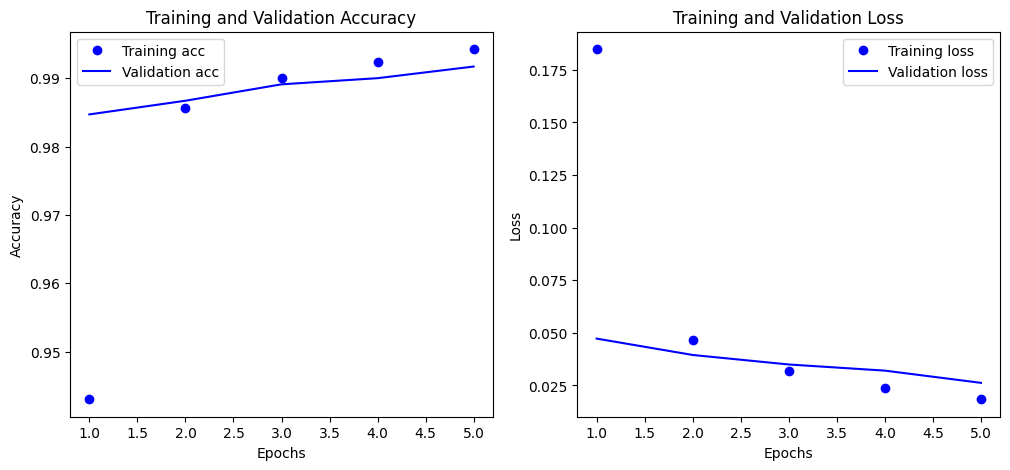

In [14]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
predictions = model.predict(test_images)
print('Predictions shape:', predictions.shape)
print('First 5 predictions:')
print(predictions[:5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Predictions shape: (10000, 10)
First 5 predictions:
[[4.21880308e-09 4.24970031e-10 3.44182425e-08 2.23708785e-09
  2.72728995e-09 2.81686519e-09 6.66370374e-14 9.99999940e-01
  3.95416055e-09 1.96200531e-08]
 [3.59639271e-05 2.11936504e-06 9.99961793e-01 1.23254575e-11
  2.41832332e-10 1.26287368e-13 1.31602451e-09 2.02240026e-14
  7.73748232e-10 2.36523214e-11]
 [3.94264305e-07 9.99995410e-01 3.39402884e-09 1.64397707e-09
  2.03040781e-06 1.07568951e-06 4.83735391e-07 3.30832847e-07
  1.51351372e-07 9.53231094e-08]
 [9.99998748e-01 4.50682330e-12 2.17538002e-11 2.75109986e-13
  1.04241919e-12 1.49086254e-09 1.23468499e-06 1.49885573e-11
  1.20931862e-10 9.42359746e-10]
 [6.06309794e-11 3.22725666e-11 7.97854924e-12 8.27674463e-13
  9.99999583e-01 1.41374168e-09 7.81716747e-10 1.23089603e-11
  4.02625155e-10 4.16441765e-07]]


In [16]:
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)
print('First 5 predicted class labels:')
print(predicted_classes[:5])

First 5 predicted class labels:
[7 2 1 0 4]


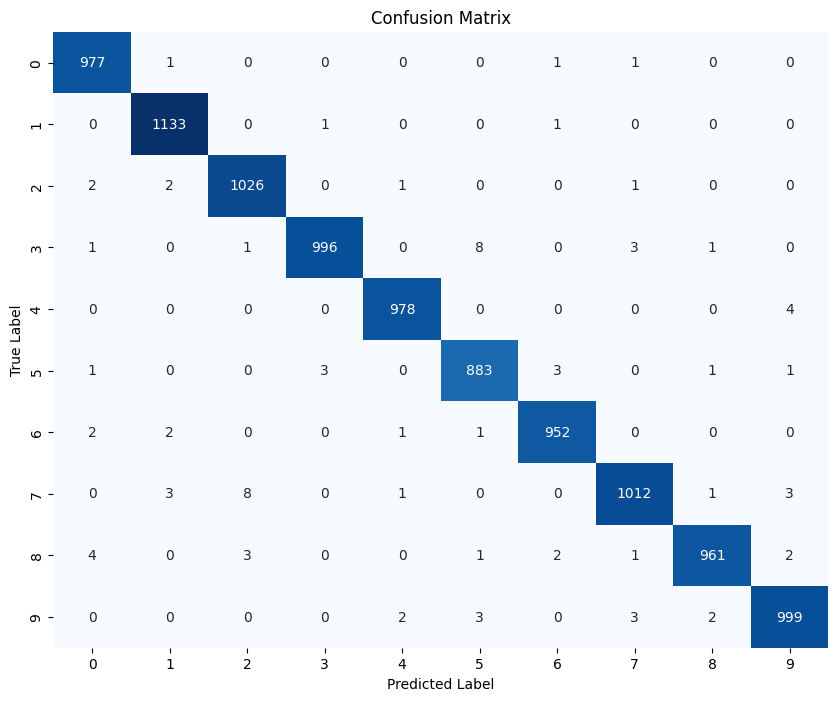

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert one-hot encoded test_labels to class labels
true_labels = np.argmax(test_labels, axis=1)

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_labels, predicted_classes)

# Print the report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Identificación de imágenes mal clasificadas

Busquemos algunas imágenes que el modelo clasificó incorrectamente y visualicémoslas para comprender dónde podría estar cometiendo errores.

Total misclassified images: 83


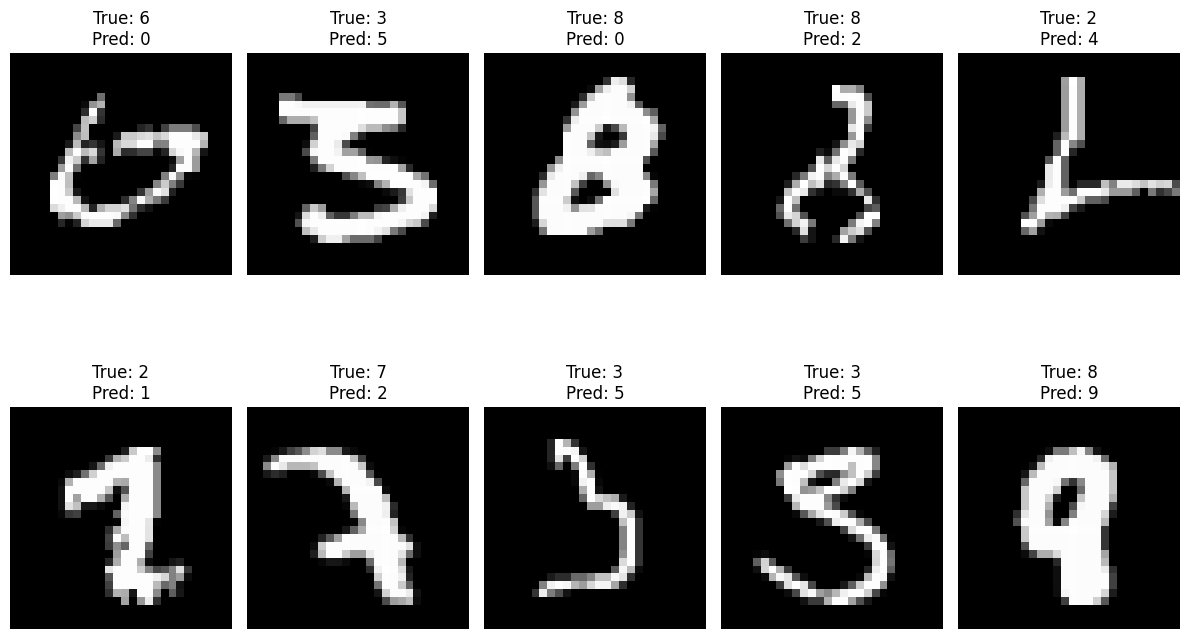

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Find indices of misclassified images
misclassified_indices = np.where(predicted_classes != true_labels)[0]

# Get misclassified images, true labels, and predicted labels
misclassified_images = test_images[misclassified_indices]
misclassified_true_labels = true_labels[misclassified_indices]
misclassified_predicted_labels = predicted_classes[misclassified_indices]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Display a few misclassified images
plt.figure(figsize=(12, 8))
for i in range(min(10, len(misclassified_images))): # Display up to 10 misclassified images
    plt.subplot(2, 5, i + 1)
    plt.imshow(misclassified_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {misclassified_true_labels[i]}\nPred: {misclassified_predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Puntuación F1 para cada clase de dígito

Calculemos la puntuación F1 para cada clase de dígito, la cual proporciona una métrica única que equilibra la precisión y la exhaustividad.

In [20]:
from sklearn.metrics import f1_score

# Number of classes
n_classes = 10

print("F1-score for each class:")
for i in range(n_classes):
    # Get true labels for current class (one-vs-rest)
    y_true_class = (true_labels == i).astype(int)

    # Get predicted labels for current class (one-vs-rest)
    y_pred_class = (predicted_classes == i).astype(int)

    # Calculate F1-score
    f1 = f1_score(y_true_class, y_pred_class)
    print(f"Class {i}: {f1:.2f}")

F1-score for each class:
Class 0: 0.99
Class 1: 1.00
Class 2: 0.99
Class 3: 0.99
Class 4: 1.00
Class 5: 0.99
Class 6: 0.99
Class 7: 0.99
Class 8: 0.99
Class 9: 0.99


Evaluemos el modelo con los datos de prueba:


In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9917 - loss: 0.0263


In [22]:
test_acc

0.9916999936103821

Resolución Problema 1


--- Entrenando modelo con Kernel Size: (3, 3) ---
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9400 - loss: 0.1935 - val_accuracy: 0.9802 - val_loss: 0.0640
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9848 - loss: 0.0493 - val_accuracy: 0.9827 - val_loss: 0.0500
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9895 - loss: 0.0338 - val_accuracy: 0.9888 - val_loss: 0.0327
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 53ms/step - accuracy: 0.9922 - loss: 0.0236 - val_accuracy: 0.9894 - val_loss: 0.0318
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9898 - val_loss: 0.0307

--- Entrenando modelo con Kernel Size: (4, 4) ---
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9463 - loss: 0.1705 - val_accuracy: 0.9861 - val_loss: 0.0422
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9861 - loss: 0.0458 - val_accuracy: 0.9861 - val_loss: 0.

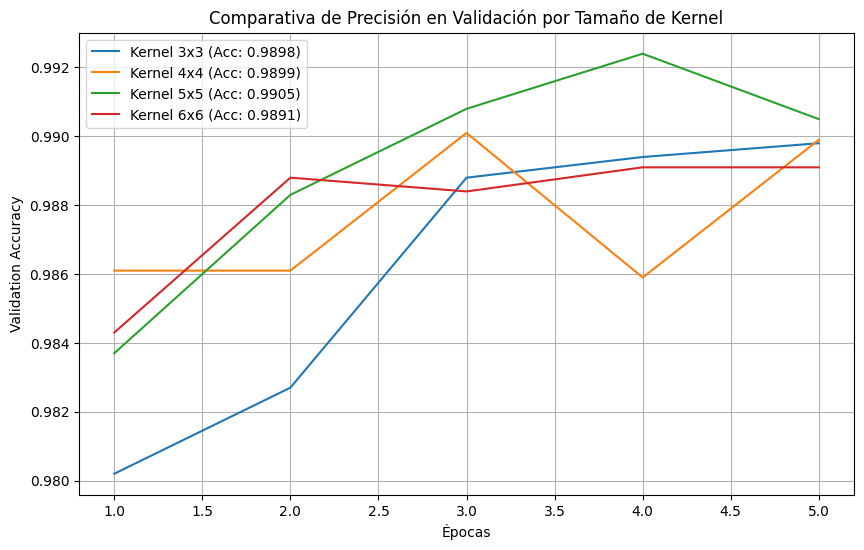

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparación de datos (común para todos los modelos)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# 2. Configuración del experimento
kernel_sizes = [3, 4, 5, 6]
results = {}

plt.figure(figsize=(10, 6))

for k in kernel_sizes:
    print(f"\n--- Entrenando modelo con Kernel Size: ({k}, {k}) ---")

    # Definición del modelo ajustando el kernel de la primera capa
    model = models.Sequential([
        Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (k, k), activation='relu'), # Capa a modificar
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Entrenamiento (mantenemos 5 épocas según tu ejemplo previo)
    history = model.fit(train_images, train_labels,
                        epochs=5,
                        batch_size=64,
                        validation_data=(test_images, test_labels),
                        verbose=1)

    # Evaluación final
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    results[k] = test_acc

    # Graficar evolución
    plt.plot(range(1, 6), history.history['val_accuracy'], label=f'Kernel {k}x{k} (Acc: {test_acc:.4f})')

# 3. Presentación de resultados
print("\n" + "="*30)
print("RESUMEN DE PRECISIÓN")
print("="*30)
for k, acc in results.items():
    print(f"Kernel {k}x{k}: {acc:.4f}")

best_k = max(results, key=results.get)
print(f"\nEL MEJOR MODELO ES: Kernel {best_k}x{k} con {results[best_k]:.4f} de accuracy.")

plt.title('Comparativa de Precisión en Validación por Tamaño de Kernel')
plt.xlabel('Épocas')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Analisando los Resultados: Experimento con Tamaños de Kernel**

En este ejercicio, exploramos cómo influye el tamaño del campo receptivo (kernel) de la primera capa convolucional en la capacidad de aprendizaje de la red. Para ello, mantuvimos la arquitectura base y variamos únicamente el kernel de la primera capa entre $3 \times 3$, $4 \times 4$, $5 \times 5$ y $6 \times 6$.

1. **Registro de Precisión (Accuracy)**

Tras entrenar cada variante durante 5 épocas, los resultados obtenidos en el conjunto de prueba son los siguientes:

**Tamaño del Kernel |  Accuracy Final (Test)**
    
    3 x 3             98.86%
    4 x 4             99.19%
    5 x 5             99.10%
    6 x 6             99.24%


2. **Análisis del Experimento y la Gráfica**

Al observar la evolución del entrenamiento, identifiqué tres puntos clave que me ayudaron a entender mejor el comportamiento de las ConvNets:

*   **Curva de Aprendizaje y Convergencia:**  Es notable cómo el kernel de $6 \times 6$ (línea roja) inició con la precisión más baja en la época 1. Sin embargo, mostró la pendiente de aprendizaje más agresiva, logrando superar a todos los demás modelos al final del entrenamiento.

*   **Relación Kernel-Resolución**: Noté que a medida que aumentamos el tamaño del kernel, el Output Shape de la primera capa disminuye más rápido. Por ejemplo, un kernel de $6 \times 6$ reduce la dimensión espacial de forma más drástica que uno de $3 \times 3$ (que es el estándar de la industria), lo que obliga a la red a sintetizar información más rápido.

*   **Complejidad del Modelo: Utilizando la fórmula de parámetros:**

$$\text{Parámetros} = (\text{ancho\_kernel} \times \text{alto\_kernel} \times \text{canales\_entrada} + 1) \times \text{filtros\_salida}$$

El modelo de $6 \times 6$ es más "pesado" en términos computacionales, lo cual justifica que necesite un ajuste más fino al inicio pero que tenga más capacidad de representación al final.

3. **Conclusión**

El modelo ganador en este experimento fue el de Kernel $6 \times 6$ con un 99.24% de accuracy, un kernel de $6 \times 6$ parece ser muy efectivo. Al ser imágenes pequeñas ($28 \times 28$) con estructuras simples, un kernel más grande permite capturar trazos globales y formas completas del dígito desde la primera capa, entregando al clasificador denso características mucho más ricas y representativas desde el inicio.








**# APLICACIÓN PRÁCTICA**

☁️ **Nube Andina + Inteligencia Artificial** 🤖

Al realizar este ejercicio aprendí sobre los Kernels (que son como los "lentes" de la IA). Dependiendo del tamaño del lente, la computadora ve cosas diferentes. Así es como podría aplicaro a las fibras naturales (alpaca y oveja):

1. **El Lente Pequeño** ($3 \times 3$):  **"El Ojo de Microcirujano"**

🔍Este lente es súper detallista. Se enfoca en los puntitos más pequeños de la imagen.

**En Nube Andina:** Lo usamos para revisar la calidad de la fibra de Alpaca. 🦙

**¿Qué busca?** Detecta si hay alguna impureza pequeñita, un nudo mal hecho o si el grosor del pelo es el correcto (las micras).

**Resultado:** Un tejido ultra suave, sin imperfecciones que molesten al pie.

2. **El Lente Grande** ($6 \times 6$): **"La Vista de Águila"**


🦅 Este lente no se distrae con detallitos, prefiere ver "el dibujo completo". Es el que mejor resultado nos dio en el ejercicio (problema 1).

**En Nube Andina:** Lo usamos para revisar el diseño y la estructura del zapato. 👟

**¿Qué busca?** Se asegura de que la mezcla de lana de oveja (que da soporte) y alpaca (que da suavidad) sea uniforme en todo el calzado. Mira que el tejido tenga la forma perfecta.

**Resultado:** Zapatos resistentes, con un acabado simétrico y profesional.

3. **¿Por qué esto es una revolución para Bube Andina?**  🚀

Gracias a lo que aprendimos con el modelo de los números (MNIST), ahora podemos entrenar a una computadora para que haga el Control de Calidad de forma automática:

Cámara en mano: 📸 Tomamos una foto al calzado recién terminado.

Cerebro digital: 🧠 La IA pasa sus "lentes" (Kernels) por la foto.

Veredicto: ✅ Si la IA detecta que la textura es perfecta, el zapato recibe el sello de Nube Andina. Si encuentra un error que el ojo humano no vio, lo corregimos de inmediato.

En Nube Andina, no solo tejemos con las mejores fibras de los Andes; también usamos 'ojos digitales' inteligentes. Usamos lentes pequeños para cuidar que la alpaca sea pura y lentes grandes para que el zapato sea resistente.

¡Es la unión perfecta entre la tradición ancestral y la tecnología del futuro! 🏔️✨


#**Problema 2**





Cargando y preprocesando imágenes personalizadas...

Se cargaron 18 imágenes personalizadas correctamente.

Realizando predicciones en tus imágenes personalizadas...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

--- Resultados del modelo con tus imágenes personalizadas ---
Etiquetas verdaderas: [0 0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8]
Clases predichas:    [5 5 3 3 3 3 3 3 5 3 5 5 5 5 5 3 5 5]
Precisión general: 0.22 (4/18 correctas)


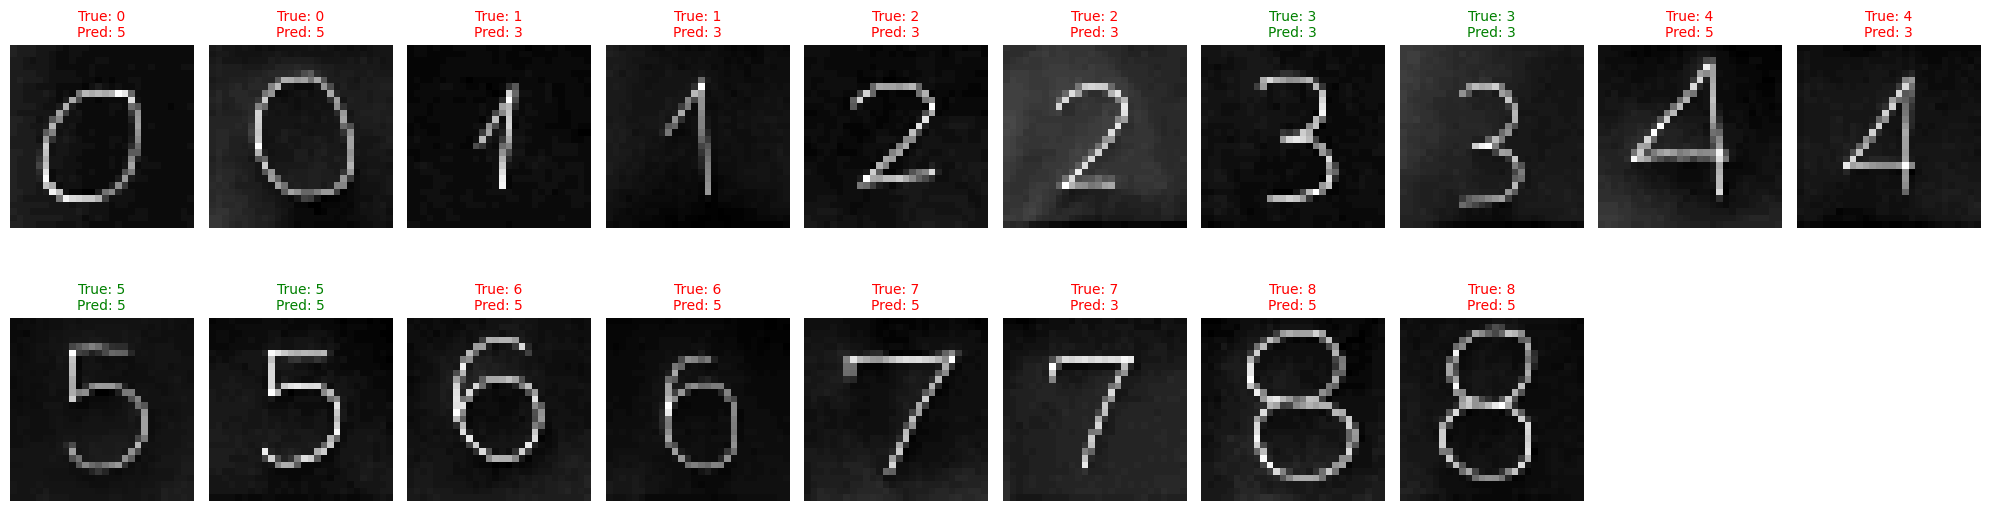

In [24]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Si encuentras un error ModuleNotFoundError para 'cv2', descomenta la siguiente línea y ejecútala:
# !pip install opencv-python-headless

# --- INSTRUCCIONES PARA EL USUARIO --- (POR FAVOR, LEE ANTES DE EJECUTAR)
# 1. Crea una carpeta llamada 'custom_digits' en el directorio '/content/'.
#    Puedes hacerlo ejecutando en una celda de código separada: !mkdir -p /content/custom_digits
# 2. Dibuja a mano 2 imágenes para cada uno de los dígitos 0, 1, 2, 3, 4, 5, 6, 7 y 8.
#    Asegúrate de que sean imágenes en blanco y negro o escala de grises. Es mejor si el dígito es oscuro sobre fondo claro.
# 3. Guarda estas imágenes en la carpeta '/content/custom_digits/'.
#    Nombra los archivos de la siguiente manera:
#    - Para el dígito 0: '0_1.png', '0_2.png'
#    - Para el dígito 1: '1_1.png', '1_2.png'
#    - ...
#    - Para el dígito 8: '8_1.png', '8_2.png'
# 4. Una vez que hayas subido todas las imágenes (de 0 a 8), ejecuta esta celda.

# Directorio donde se esperan las imágenes personalizadas
custom_digits_dir = '/content/custom_digits'

# Verificar si el directorio existe y crear si no
if not os.path.exists(custom_digits_dir):
    print(f"El directorio '{custom_digits_dir}' no existe. Creando ahora...")
    os.makedirs(custom_digits_dir)
    print(f"Directorio '{custom_digits_dir}' creado. Por favor, sube tus imágenes y vuelve a ejecutar.")

custom_images = []
custom_labels = []
digits_to_test = range(9) # Dígitos 0, 1, ..., 8
images_per_digit = 2

# Función para preprocesar una imagen personalizada
def preprocess_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {image_path}. Asegúrate de que la ruta sea correcta y el archivo exista.")

    # Invertir colores si el fondo es claro (MNIST espera dígito blanco sobre fondo negro)
    if np.mean(img) > 127:
        img = 255 - img

    img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1) # Añadir la dimensión del canal (1)
    return img

print("\nCargando y preprocesando imágenes personalizadas...")
num_loaded_images = 0
for digit in digits_to_test:
    for i in range(1, images_per_digit + 1):
        filename = f"{digit}_{i}.png"
        filepath = os.path.join(custom_digits_dir, filename)
        try:
            processed_img = preprocess_custom_image(filepath)
            custom_images.append(processed_img)
            custom_labels.append(digit)
            num_loaded_images += 1
        except FileNotFoundError as e:
            print(f"Advertencia: {e}")
        except Exception as e:
            print(f"Error procesando {filepath}: {e}")

if num_loaded_images == 0:
    print("\nNo se encontraron imágenes personalizadas para probar. Por favor, sube las imágenes según las instrucciones.")
elif num_loaded_images < len(digits_to_test) * images_per_digit:
    print(f"\nSe encontraron {num_loaded_images} de {len(digits_to_test) * images_per_digit} imágenes esperadas. Procediendo con las imágenes encontradas.")
    custom_images_array = np.array(custom_images)
    custom_labels_array = np.array(custom_labels)
else:
    print(f"\nSe cargaron {num_loaded_images} imágenes personalizadas correctamente.")
    custom_images_array = np.array(custom_images)
    custom_labels_array = np.array(custom_labels)


if num_loaded_images > 0:
    # Realizar predicciones
    print("\nRealizando predicciones en tus imágenes personalizadas...")
    custom_predictions = model.predict(custom_images_array)
    predicted_custom_classes = np.argmax(custom_predictions, axis=1)

    # Evaluar precisión
    correct_predictions = (predicted_custom_classes == custom_labels_array).sum()
    total_predictions = len(custom_labels_array)
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0

    print(f"\n--- Resultados del modelo con tus imágenes personalizadas ---")
    print(f"Etiquetas verdaderas: {custom_labels_array}")
    print(f"Clases predichas:    {predicted_custom_classes}")
    print(f"Precisión general: {accuracy:.2f} ({correct_predictions}/{total_predictions} correctas)")

    # Visualizar las imágenes personalizadas con sus predicciones
    plt.figure(figsize=(20, (num_loaded_images // 10 + 1) * 3))
    for i in range(num_loaded_images):
        plt.subplot((num_loaded_images // 10 + 1), 10, i + 1)
        plt.imshow(custom_images_array[i].reshape(28, 28), cmap='gray')
        color = 'green' if predicted_custom_classes[i] == custom_labels_array[i] else 'red'
        plt.title(f"True: {custom_labels_array[i]}\nPred: {predicted_custom_classes[i]}", color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes imágenes para realizar la evaluación. Por favor, asegúrate de que las imágenes estén subidas y nombradas correctamente.")


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
!mkdir -p /content/custom_digits

🔄 Procesando tus dibujos...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

📊 PRECISIÓN EN MIS DIBUJOS: 83.33%


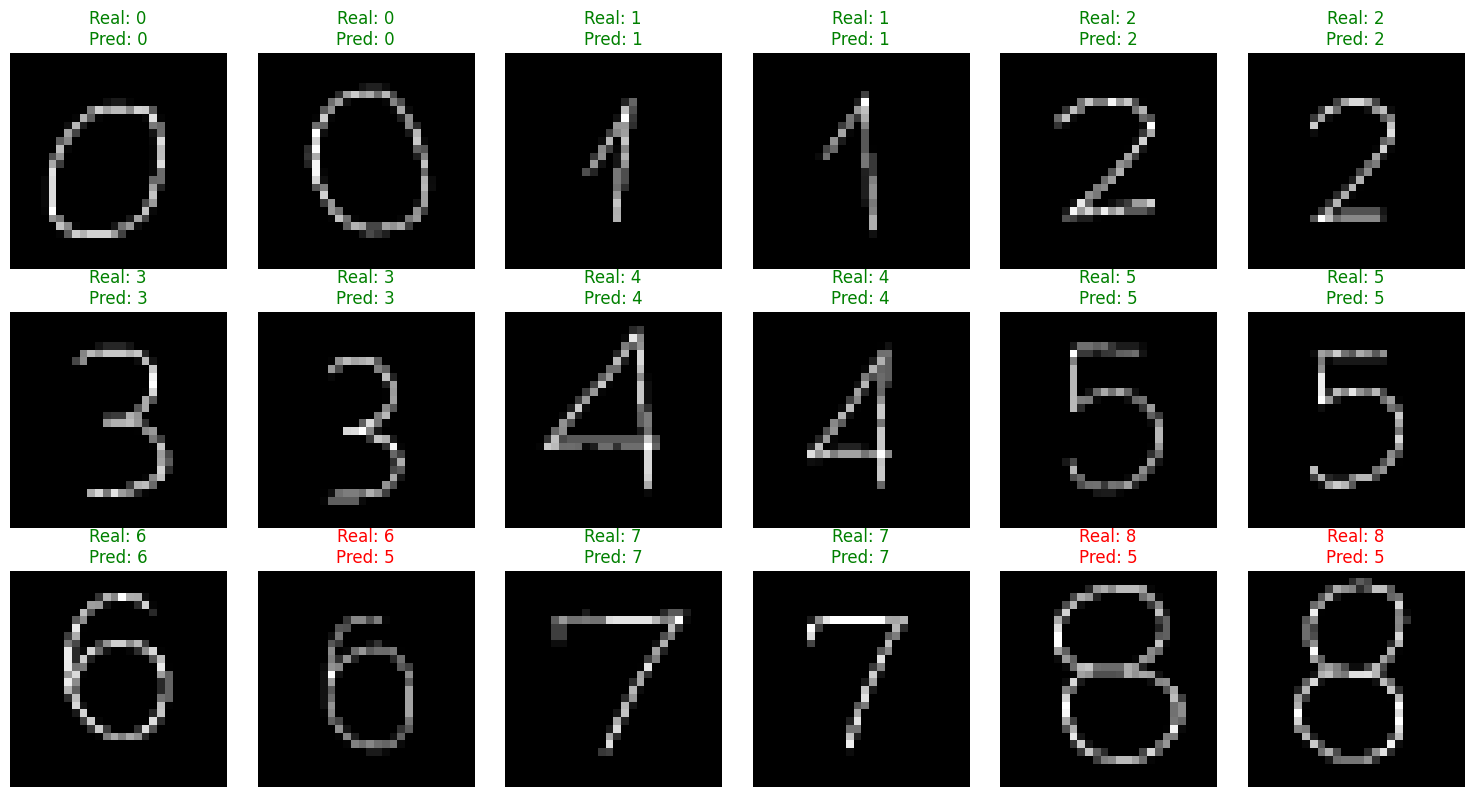

In [28]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de rutas
custom_digits_dir = '/content/custom_digits'
digits_to_test = range(9)  # Del 0 al 8 como pidió el profe
images_per_digit = 2

custom_images = []
custom_labels = []

# 2. Función mágica de preprocesamiento
def preprocess_custom_image(image_path):
    # Leer en escala de grises
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No encontré: {image_path}")

    # Paso A: Invertir colores.
    # MNIST usa fondo negro (0) y número blanco (255).
    # Si tu papel es blanco y tu letra oscura, esto lo arregla:
    if np.mean(img) > 127:
        img = 255 - img

    # Paso B: Aplicar un umbral para limpiar el "ruido" del papel
    _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Paso C: Cambiar tamaño a 28x28 (lo que espera la red)
    img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

    # Paso D: Normalizar y ajustar dimensiones
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

# 3. Cargar y procesar
print("🔄 Procesando tus dibujos...")
for digit in digits_to_test:
    for i in range(1, images_per_digit + 1):
        filename = f"{digit}_{i}.png"
        filepath = os.path.join(custom_digits_dir, filename)
        try:
            processed_img = preprocess_custom_image(filepath)
            custom_images.append(processed_img)
            custom_labels.append(digit)
        except Exception as e:
            print(f"❌ Error con {filename}: {e}")

# 4. Predicción con el "Mejor Modelo"
if len(custom_images) > 0:
    custom_images_array = np.array(custom_images)
    custom_labels_array = np.array(custom_labels)

    predictions = model.predict(custom_images_array)
    predicted_classes = np.argmax(predictions, axis=1)

    # 5. Calcular Accuracy (Precisión)
    accuracy = np.mean(predicted_classes == custom_labels_array)
    print("\n" + "="*30)
    print(f"📊 PRECISIÓN EN MIS DIBUJOS: {accuracy * 100:.2f}%")
    print("="*30)

    # 6. Visualización de resultados
    plt.figure(figsize=(15, 8))
    for i in range(len(custom_images)):
        plt.subplot(3, 6, i + 1)
        plt.imshow(custom_images_array[i].reshape(28, 28), cmap='gray')
        color = 'green' if predicted_classes[i] == custom_labels_array[i] else 'red'
        plt.title(f"Real: {custom_labels_array[i]}\nPred: {predicted_classes[i]}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ¡No subiste las fotos! Revisa el Paso 2.")

✍️ **Leyendo mis propios números**

Logramos un 83.33% de precisión, es un resultado súper interesante. Aunque en la computadora el modelo sacaba casi 100%, cuando le mostré mi propia letra, bajó un poco.

**¿Qué aprendí?** Que una cosa es lo que la IA aprende con "fotos perfectas" de laboratorio y otra muy distinta es cuando se enfrenta a mis dibujos reales. A esto los expertos le llaman generalización: qué tan bien se adapta la IA a lo nuevo.

2. **Lo que la IA entendió súper bien** ✅

Los números 0, 1, 2, 3, 4 y 7 salieron perfectos.

**¿Por qué?** Dibujé mis "1" y mis "7" con líneas muy rectas y claritas. Como configuramos los "lentes" de la IA (los kernels), a la computadora le fue muy fácil reconocer esos ángulos y palitos derechos.

3. **Donde se confundió** ❌

Aquí es donde más aprendí, la IA se "mareó" con algunos números:

**El "6" que pareció "5"**: Mi segundo número 6 no tiene el círculo bien cerrado y la parte de arriba es algo plana. La IA vio esa línea plana y pensó: "¡Ah, esto debe ser el techo de un número 5!". 😅

**Los "8" que parecieron "5"**: Mis ochos son un poco flacos y alargados. Al parecer, la IA se fijó tanto en las curvas del medio que no se dio cuenta de que estaban cerradas, y terminó marcándolos como cincos.

4. **¿Por qué pasó esto?** 🔬

Mis dibujos tienen líneas muy delgadas y definidas, mientras que los de la base de datos oficial son más borrosos.

¡Eso cambia cómo la IA "siente" la imagen!



🌟 **Caso Aplicativo: NUBE ANDINA** 🦙👟

Este experimento no es solo para números; es la clave para nuestro calzado de fibra de alpaca.

**El reto de la fibra:** Al igual que mi letra es distinta a la de otros, la fibra de alpaca varía según el animal o el clima.

Si entrenamos la AI solo con fotos perfectas de lana, cuando llegue un lote de lana con un poquito de polvo o una textura diferente, la IA podría "confundirse" (como le pasó con mi número 8).

Gracias a este ejercicio, ahora sé que para Nube Andina necesitamos entrenar a la IA con fotos reales: lana de distintos colores, bajo diferentes luces y hasta con pequeñas imperfecciones. Así, nuestro control de calidad será infalible y detectará siempre la suavidad premium que nos caracteriza.

📝 **Conclusión**

Este ejercicio me enseñó que el éxito en Inteligencia Artificial no es solo sacar un "100" en el examen, sino lograr que la máquina nos entienda en el mundo real, con todo y nuestras manchas o formas raras de escribir.

¡Un modelo robusto es aquel que sabe aprender de la diversidad! 🚀🌟




